# Phase 2: Embodied Latent Adapter (Delta Model)
This notebook trains a Continuous Autoregressive Transformer to predict exact geometric stroke vectors from text prompts. 
It bridges a frozen text encoder (`openai/clip-vit-base-patch32`) with a custom continuous-space decoder.

**Hardware Optimization:** Designed for 4GB VRAM environments using Automatic Mixed Precision (AMP) and Gradient Accumulation.

In [29]:
import os
import json
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from transformers import CLIPTextModel, CLIPTokenizer
import matplotlib.pyplot as plt
import numpy as np

# Suppress HuggingFace warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute Device: {device}")
if torch.cuda.is_available():
    print(f"VRAM Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Compute Device: cuda
VRAM Available: 4.00 GB


In [2]:
from transformers import CLIPTokenizer, CLIPTextModel

model_id = "openai/clip-vit-base-patch32"

# Download from Hugging Face (requires internet once)
tokenizer = CLIPTokenizer.from_pretrained(model_id)
text_encoder = CLIPTextModel.from_pretrained(model_id)

# Save locally in current directory
tokenizer.save_pretrained("./clip-vit-base-patch32-local")
text_encoder.save_pretrained("./clip-vit-base-patch32-local")


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
logit_scale                                                    | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.l

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

c:\Users\PRIYANSHU SINGH\Desktop\Desk\AI\genAI\GpuEnvs\pygpu-env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PRIYANSHU SINGH\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## 1. Data Loading & Sequence Padding
Unlike discrete text tokens, continuous strokes vary in sequence length. We must pad all sequences to a maximum length ($N_{max}$) using a dummy vector (e.g., `[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]`) so they fit into a uniform batch tensor. 

The target labels represent: `[x1, y1, x2, y2, thickness, opacity]`.

In [8]:
class StrokeDataset(Dataset):
    def __init__(self, json_path, max_seq_len=30):
        with open(json_path, 'r') as f:
            data_dict = json.load(f)
        
        # Convert dictionary to list of values for indexed access
        self.data = list(data_dict.values())
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Generate a generic prompt based on category if available
        if "category" in item:
            prompt = f"Draw a {item['category'].replace('gen_', '')}"
        else:
            prompt = "Draw something"
        
        strokes = torch.tensor(item["strokes"], dtype=torch.float32)
        
        # Truncate if too long
        if strokes.shape[0] > self.max_seq_len:
            strokes = strokes[:self.max_seq_len]
            
        # Pad sequence with zeros if too short
        pad_len = self.max_seq_len - strokes.shape[0]
        if pad_len > 0:
            padding = torch.zeros((pad_len, 6), dtype=torch.float32)
            strokes = torch.cat([strokes, padding], dim=0)
            
        return prompt, strokes

# Instantiate DataLoader
# Using a very small batch size to protect limited VRAM
dataset = StrokeDataset("data/dataset/annotations.json", max_seq_len=20)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, drop_last=True)
print(f"Dataset loaded: {len(dataset)} samples. Batches: {len(dataloader)}")

Dataset loaded: 2000 samples. Batches: 500


## 2. Model Architecture
The `DeltaContinuousModel` uses a frozen CLIP text encoder to extract a 512-dimensional semantic embedding from the user's prompt. 

The Decoder utilizes **Teacher Forcing** during training: it receives the ground-truth sequence shifted by one step and predicts the next continuous vector. The final output passes through a Sigmoid activation to bound the coordinates:
$$\hat{S}_t \in [0, 1]^6$$

In [9]:
local_path = "./clip-vit-base-patch32-local"

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 200):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)].transpose(0, 1)

class DeltaContinuousModel(nn.Module):
    def __init__(self, d_model=512, nhead=8, num_layers=4):
        super().__init__()
        # 1. Frozen Text Encoder
        self.tokenizer = CLIPTokenizer.from_pretrained(local_path)
        self.text_encoder = CLIPTextModel.from_pretrained(local_path)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
            
        # 2. Continuous Embedder & Start-of-Sequence Token
        self.stroke_embedding = nn.Linear(6, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.sos_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # 3. Transformer Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=1024, 
            batch_first=True, norm_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        # 4. Regression Output Head
        self.output_head = nn.Sequential(
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Linear(256, 6),
            nn.Sigmoid() # Bounds output to canvas [0.0, 1.0]
        )

    def generate_causal_mask(self, sz, device):
        mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        return mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))

    def forward(self, text_prompts, target_strokes):
        batch_size, seq_len, _ = target_strokes.shape
        
        # Encode Text
        text_inputs = self.tokenizer(text_prompts, padding=True, return_tensors="pt").to(device)
        with torch.no_grad():
            encoder_hidden_states = self.text_encoder(**text_inputs).last_hidden_state
            
        # Embed previous strokes (shifted right)
        stroke_embeds = self.stroke_embedding(target_strokes)
        sos_expanded = self.sos_token.expand(batch_size, -1, -1)
        decoder_inputs = torch.cat([sos_expanded, stroke_embeds[:, :-1, :]], dim=1)
        decoder_inputs = self.pos_encoder(decoder_inputs)
        
        # Autoregressive decoding
        tgt_mask = self.generate_causal_mask(seq_len, device)
        hidden_states = self.transformer_decoder(
            tgt=decoder_inputs, memory=encoder_hidden_states, tgt_mask=tgt_mask
        )
        
        return self.output_head(hidden_states)

# Initialize Model
model = DeltaContinuousModel().to(device)
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Trainable Parameters: 12,754,694


## 3. Training Loop (Memory Optimized)
Because continuous output spaces require larger batch sizes to stabilize gradients, we use **Gradient Accumulation** to simulate a batch size of 32 while only physically loading 4 samples into VRAM at a time. We also implement `torch.cuda.amp` to train in FP16 precision.

The loss function is standard Mean Squared Error ($L_2$ Loss).

Starting Autoregressive Continuous Training...
Epoch 05/50 | MSE Loss: 0.00512
Epoch 10/50 | MSE Loss: 0.00485
Epoch 15/50 | MSE Loss: 0.00460
Epoch 20/50 | MSE Loss: 0.00436
Epoch 25/50 | MSE Loss: 0.00415
Epoch 30/50 | MSE Loss: 0.00408
Epoch 35/50 | MSE Loss: 0.00397
Epoch 40/50 | MSE Loss: 0.00373
Epoch 45/50 | MSE Loss: 0.00368
Epoch 50/50 | MSE Loss: 0.00343


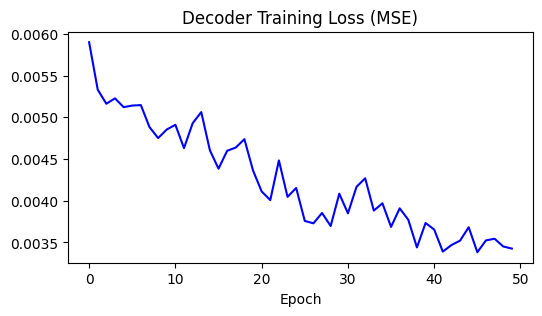

In [11]:
# Hyperparameters
epochs = 50
learning_rate = 1e-4
accumulation_steps = 8 # Simulates Batch Size = 32

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
criterion = nn.MSELoss()
scaler = torch.amp.GradScaler("cuda")

model.train()
loss_history = []

print("Starting Autoregressive Continuous Training...")
for epoch in range(epochs):
    optimizer.zero_grad()
    total_loss = 0.0
    
    for batch_idx, (prompts, targets) in enumerate(dataloader):
        targets = targets.to(device)
        
        # Forward pass in Mixed Precision
        with torch.amp.autocast(device_type=device.type):
            predictions = model(prompts, targets)
            loss = criterion(predictions, targets) / accumulation_steps
            
        # Scaled Backward Pass
        scaler.scale(loss).backward()
        total_loss += (loss.item() * accumulation_steps)
        
        # Accumulate gradients before updating weights
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(dataloader):
            # Clip gradients to prevent exploding vectors
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | MSE Loss: {avg_loss:.5f}")

plt.figure(figsize=(6, 3))
plt.plot(loss_history, color='blue')
plt.title("Decoder Training Loss (MSE)")
plt.xlabel("Epoch")
plt.show()

In [12]:
save_folder = "./adapter_checkpoint"
os.makedirs(save_folder, exist_ok=True)

# Save tokenizer and any associated tokenizer files
tokenizer.save_pretrained(save_folder)

# Save model weights safely
torch.save(model.state_dict(), os.path.join(save_folder, "delta_continuous_model_state.pth"))

print(f"Saved adapter checkpoint to: {save_folder}")

Saved adapter checkpoint to: ./adapter_checkpoint


## 5. Loading Saved Adapter Model
Load the previously saved model, tokenizer, and adapter from the checkpoint directory.


In [30]:
def load_adapter_model(checkpoint_path="./adapter_checkpoint"):
    """
    Load the saved DeltaContinuousModel, tokenizer, and weights.
    
    Args:
        checkpoint_path: Path to the folder containing the saved checkpoint
        
    Returns:
        loaded_model: The initialized model with loaded weights
        loaded_tokenizer: The loaded CLIP tokenizer
    """
    # Load the tokenizer from saved checkpoint
    from transformers import CLIPTokenizer, CLIPTextModel
    loaded_tokenizer = CLIPTokenizer.from_pretrained(checkpoint_path)
    
    # Initialize a fresh model instance with the same architecture
    loaded_model = DeltaContinuousModel().to(device)
    
    # Load the saved state dictionary
    state_dict_path = os.path.join(checkpoint_path, "delta_continuous_model_state.pth")
    loaded_model.load_state_dict(torch.load(state_dict_path, map_location=device))
    
    # Set model to evaluation mode
    loaded_model.eval()
    
    print(f"✓ Model loaded from: {checkpoint_path}")
    print(f"✓ Tokenizer loaded successfully")
    print(f"✓ Model is in evaluation mode")
    
    return loaded_model, loaded_tokenizer

# Example usage:
# restored_model, restored_tokenizer = load_adapter_model("./adapter_checkpoint")


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

✓ Model loaded from: ./adapter_checkpoint
✓ Tokenizer loaded successfully
✓ Model is in evaluation mode

Generating: Draw a flowchart


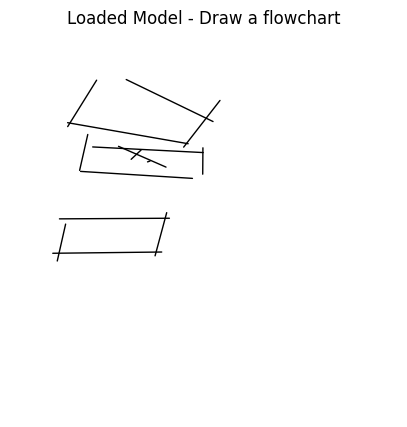


Generating: Draw a triangle


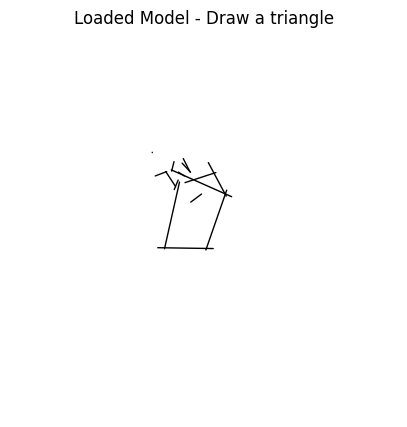


Generating: Draw a star


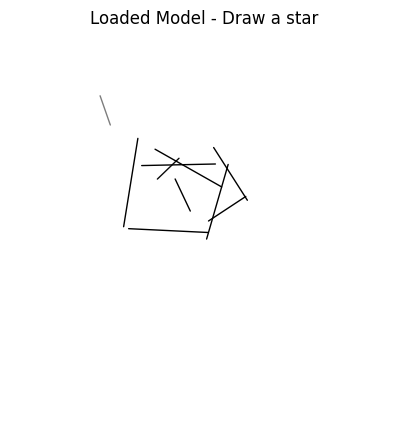

In [32]:
# --- Example: Load and Use the Adapter Model ---
# Uncomment and run to load your saved model:

restored_model, restored_tokenizer = load_adapter_model("./adapter_checkpoint")

# Generate a drawing with the loaded model
test_prompts = ["Draw a flowchart", "Draw a triangle", "Draw a star"]

for prompt in test_prompts:
    print(f"\nGenerating: {prompt}")
    strokes = generate_drawing(prompt, restored_model, max_strokes=15)
    render_strokes_to_matplotlib(strokes, title=f"Loaded Model - {prompt}")


## 4. Evaluation & Visual Validation
During inference, we don't have ground-truth strokes to feed the decoder. We must implement an autoregressive generator loop. 
The model starts with the `[SOS]` token, predicts Stroke 1, appends it to the sequence, and predicts Stroke 2, repeating until the maximum sequence length is reached or the model predicts an opacity of `0.0` (signaling it has finished drawing).

Generating vectors for: 'Draw a structural flowchart'...

Raw Output Tensor (First 3 Strokes):
[[0.313 0.144 0.515 0.244 0.027 0.999]
 [0.535 0.183 0.455 0.308 0.03  1.   ]
 [0.458 0.3   0.166 0.253 0.025 1.   ]]


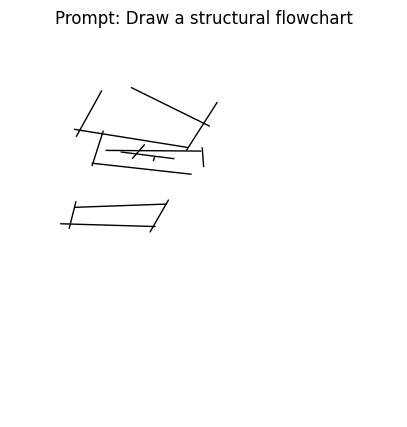

In [31]:
def generate_drawing(prompt, model, max_strokes=15):
    model.eval()
    
    with torch.no_grad():
        # 1. Encode the text prompt
        text_inputs = model.tokenizer([prompt], padding=True, return_tensors="pt").to(device)
        encoder_hidden_states = model.text_encoder(**text_inputs).last_hidden_state
        
        # 2. Initialize empty stroke sequence
        # Shape: [1, seq_len, 6]
        current_strokes = torch.zeros((1, 0, 6), device=device)
        
        for step in range(max_strokes):
            # Embed generated strokes so far
            if current_strokes.size(1) > 0:
                stroke_embeds = model.stroke_embedding(current_strokes)
                decoder_inputs = torch.cat([model.sos_token, stroke_embeds], dim=1)
            else:
                decoder_inputs = model.sos_token
                
            decoder_inputs = model.pos_encoder(decoder_inputs)
            tgt_mask = model.generate_causal_mask(decoder_inputs.size(1), device)
            
            # Predict next step
            hidden_states = model.transformer_decoder(
                tgt=decoder_inputs, memory=encoder_hidden_states, tgt_mask=tgt_mask
            )
            
            # Extract only the prediction for the newest step
            next_stroke_pred = model.output_head(hidden_states[:, -1:, :])
            
            # Append to our sequence
            current_strokes = torch.cat([current_strokes, next_stroke_pred], dim=1)
            
    return current_strokes.squeeze(0).cpu().numpy()

def render_strokes_to_matplotlib(strokes, title="AI Generated Canvas"):
    """Validates the output by drawing the mathematical vectors onto a pyplot canvas."""
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0) # Invert Y-axis to match image coordinates
    ax.set_title(title)
    
    for stroke in strokes:
        x1, y1, x2, y2, thickness, opacity = stroke
        
        # Only draw lines the AI intended to be visible
        if opacity > 0.3:
            # Map normalized thickness to matplotlib linewidth
            lw = max(1.0, thickness * 15.0) 
            ax.plot([x1, x2], [y1, y2], color='black', alpha=opacity, linewidth=lw, solid_capstyle='round')
            
    plt.axis('off')
    plt.show()

# --- Run Validation ---
test_prompt = "Draw a structural flowchart"
print(f"Generating vectors for: '{test_prompt}'...")
generated_vectors = generate_drawing(test_prompt, model)

# Print raw mathematical output
print("\nRaw Output Tensor (First 3 Strokes):")
print(np.round(generated_vectors[:3], 3))

# Render visual
render_strokes_to_matplotlib(generated_vectors, title=f"Prompt: {test_prompt}")

In [14]:
def test(test_prompt):
    print(f"Generating vectors for: '{test_prompt}'...")
    generated_vectors = generate_drawing(test_prompt, model)

    # Print raw mathematical output
    print("\nRaw Output Tensor (First 3 Strokes):")
    print(np.round(generated_vectors[:3], 3))

    # Render visual
    render_strokes_to_matplotlib(generated_vectors, title=f"Prompt: {test_prompt}")

Generating vectors for: 'Draw a number 7'...

Raw Output Tensor (First 3 Strokes):
[[0.314 0.309 0.504 0.364 0.026 0.999]
 [0.486 0.364 0.486 0.529 0.031 0.999]
 [0.469 0.543 0.3   0.549 0.026 1.   ]]


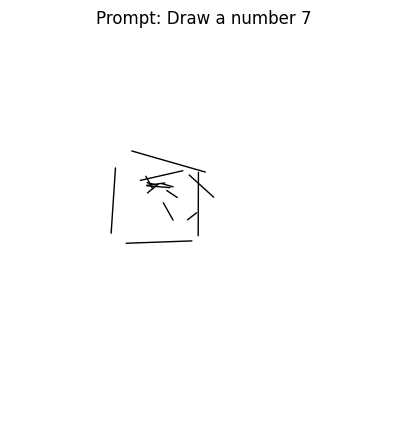

In [26]:
test("Draw a number 7")

In [ ]:
import matplotlib.pyplot as plt
import torch
import textwrap

def render_multiple_prompts(prompts, ncols=3, model=None, max_strokes=15, title="AI Generated Gallery"):
    """
    Render multiple text prompts as stroke drawings on a single matplotlib canvas.
    
    Args:
        prompts: list of strings (text prompts)
        ncols: number of columns in the grid
        model: your trained drawing model
        max_strokes: maximum strokes per drawing
        title: overall canvas title
    """
    n = len(prompts)
    nrows = (n + ncols - 1) // ncols  # ceil division
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16)
    
    for idx, prompt in enumerate(prompts):
        # Generate strokes for this prompt
        strokes = generate_drawing(prompt, model, max_strokes=max_strokes)
        
        ax = axes[idx]
        ax.set_xlim(0, 1)
        ax.set_ylim(1, 0)  # invert Y-axis
        ax.axis("off")
        
        # Wrap long prompt into max 2 lines
        wrapped_prompt = "\n".join(textwrap.wrap(prompt, width=30, max_lines=2, placeholder="..."))
        ax.set_title(wrapped_prompt, fontsize=10)
        
        # Draw strokes
        for stroke in strokes:
            x1, y1, x2, y2, thickness, opacity = stroke
            if opacity > 0.3:
                lw = max(1.0, thickness * 15.0)
                ax.plot([x1, x2], [y1, y2], color="black", alpha=opacity,
                        linewidth=lw, solid_capstyle="round")
    
    # Hide unused axes if prompts < nrows*ncols
    for j in range(idx+1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()


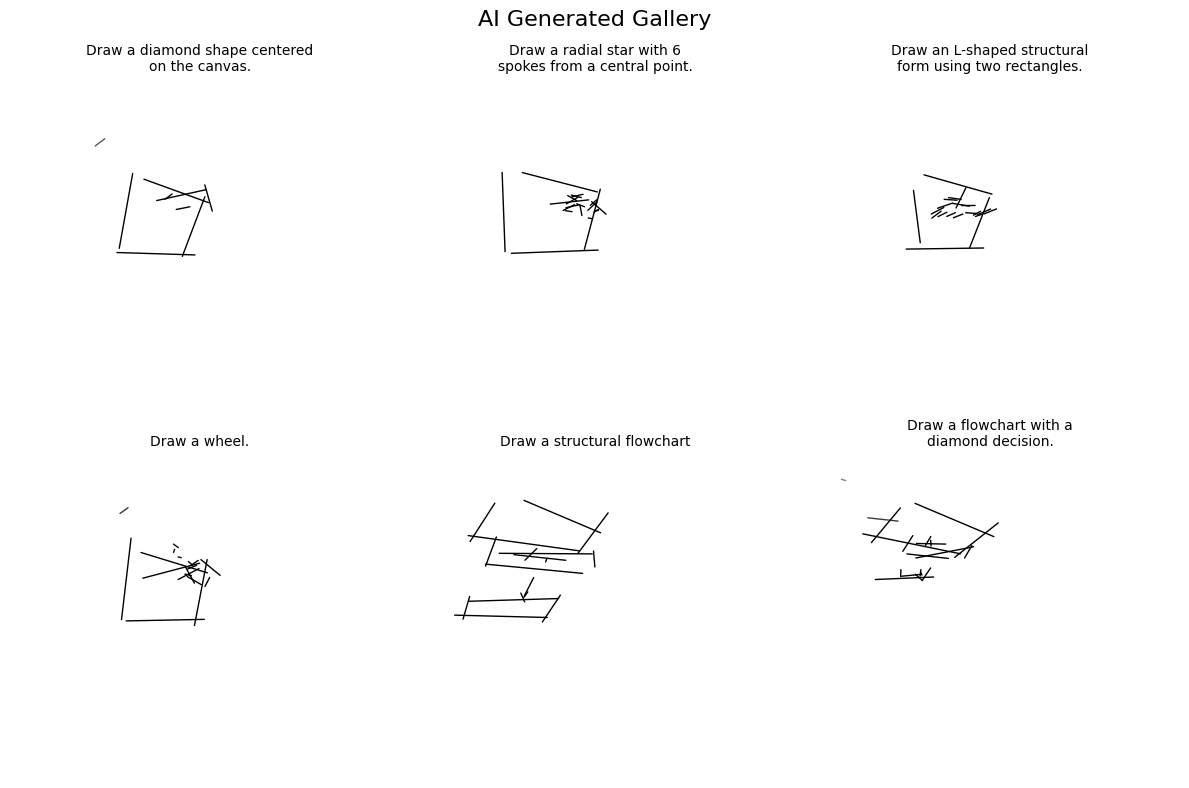

In [37]:
prompts = [
    "Draw a diamond shape centered on the canvas.",
    "Draw a radial star with 6 spokes from a central point.",
    "Draw an L-shaped structural form using two rectangles.",
    "Draw a wheel.",
    "Draw a structural flowchart",
    "Draw a flowchart with a diamond decision."
]

render_multiple_prompts(prompts, ncols=3, model=restored_model, max_strokes=20)


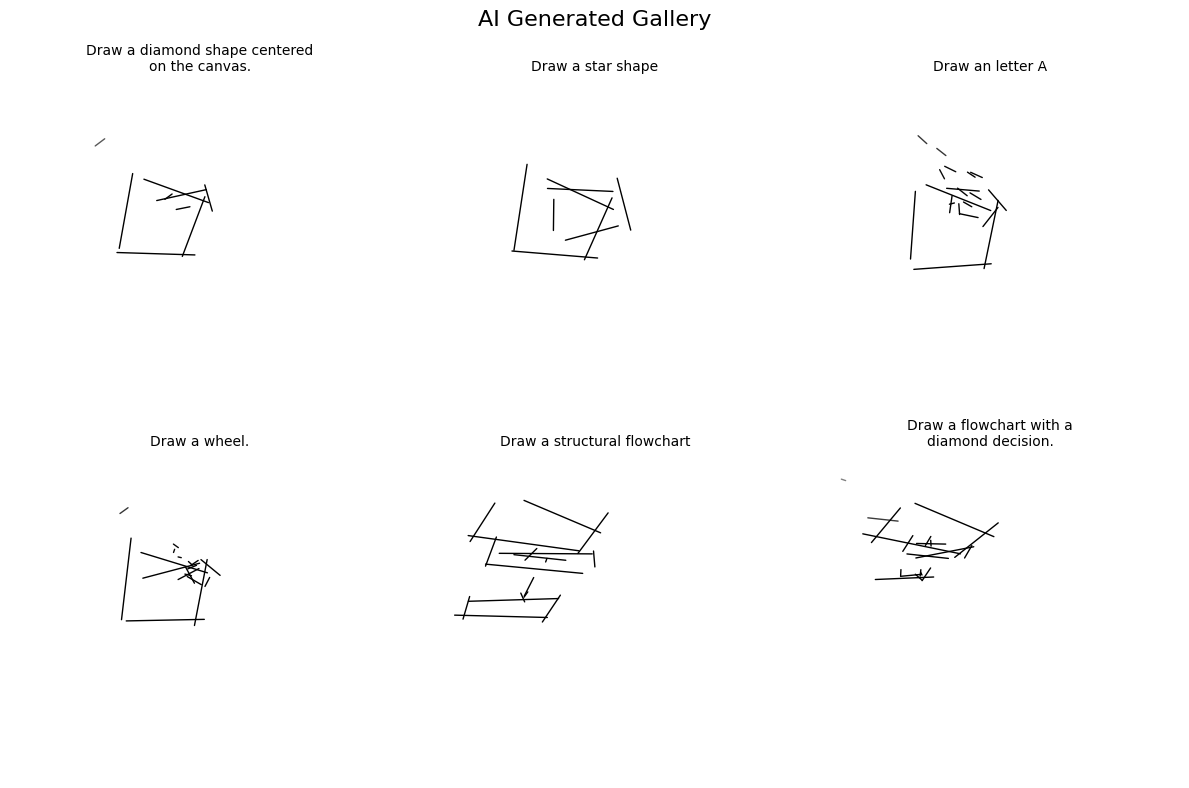

In [39]:
prompts = [
    "Draw a diamond shape centered on the canvas.",
    "Draw a star shape",
    "Draw an letter A",
    "Draw a wheel.",
    "Draw a structural flowchart",
    "Draw a flowchart with a diamond decision."
]

render_multiple_prompts(prompts, ncols=3, model=restored_model, max_strokes=20)
